<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [12]:
dataset['train']['text'][0]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [14]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
dataset['train']['text'][0]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

In [47]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for sentence in tqdm(dataset['train']['text']):
  sentences.extend([x.lower() for x in sent_tokenize(sentence, language='english') if len(word_tokenize(x)) < word_threshold])

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

In [48]:
print("Всего предложений:", len(sentences))

Всего предложений: 397602


Посчитаем для каждого слова его встречаемость.

In [49]:
sentences[0]

'i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967.'

In [50]:
words = Counter()

# Расчет встречаемости слов
for sequence in tqdm(sentences):
  for word in word_tokenize(sequence):
    words[word] += 1

print(len(words))

  0%|          | 0/397602 [00:00<?, ?it/s]

68415


Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [51]:
words.most_common(10)

[('.', 340378),
 ('the', 302576),
 (',', 228242),
 ('a', 150546),
 ('and', 146318),
 ('of', 125592),
 ('to', 120988),
 ('is', 114936),
 ('it', 103724),
 ('i', 97978)]

In [52]:
vocab = set()
vocab_size = 40000

# Наполнение словаря
vocab.update([word for word, count in words.most_common(vocab_size)])
vocab.update(['<unk>', '<bos>', '<eos>', '<pad>'])


In [53]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [54]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [45]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [55]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        # Допишите код здесь
        tokenized_sentence += [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx])]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [56]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [58]:
# Здесь изначально была ошибка с утечкой данных. Исправил ее сам
train_sentences, temp_sentences = train_test_split(sentences, test_size=0.2, random_state=42)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5, random_state=42)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [87]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids'])
            logits_flat = logits.reshape(-1, logits.size(-1))
            targets_flat = batch['target_ids'].flatten()

            loss = criterion(logits_flat, targets_flat)

            non_pad_tokens = (targets_flat != criterion.ignore_index).sum().item()
            total_loss += loss.item() * non_pad_tokens
            total_tokens += non_pad_tokens

    if total_tokens == 0:
        return float('inf')

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [68]:
def train_model(model, train_dataloader, eval_dataloader, criterion=nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']),
                num_epoch=10, lr=0.001):
    # Напишите код здесь
    losses, perplexities = [], []
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epoch):
      epoch_losses = []
      model.train()

      for batch in tqdm(train_dataloader, desc=f'Training epoch = {epoch + 1}: '):
        optimizer.zero_grad()
        logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)

        loss = criterion(logits, batch['target_ids'].flatten())
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

      avg_train_loss = sum(epoch_losses) / len(epoch_losses)
      losses.append(avg_train_loss)

      eval_perplexity = evaluate(model, criterion, eval_dataloader)
      perplexities.append(eval_perplexity)

      print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Eval Perplexity = {eval_perplexity:.4f}")

    return model, losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

Определяю бэйзлайн архитектуру - один слой LSTM, в качестве нелинейных слоев беру гиперболический тангенс. Испльзую один линейный слой после нелинейного преборазования выхода рекуррентного слоя, один - в качества прекции на пространство слов (словаря) для формирования итогового ответа

In [69]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()

        # Опишите свою нейронную сеть здесь
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.tanh = nn.Tanh()
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        out = self.embedding(input_batch)
        out, _ = self.lstm(out)
        out = self.tanh(out)
        out = self.linear(out)
        out = self.tanh(out)
        out = self.projection(out)

        return out

In [71]:
# Обучите модель здесь
model, losses, perplexities = train_model(LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device), train_dataloader, eval_dataloader)


Training epoch = 1:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 1: Train Loss = 5.0563, Eval Perplexity = 103.8021


Training epoch = 2:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 2: Train Loss = 4.4466, Eval Perplexity = 82.4666


Training epoch = 3:   0%|          | 0/2486 [00:00<?, ?it/s]

...

Epoch 8: Train Loss = 3.5166, Eval Perplexity = 57.8510


Training epoch = 9:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 9: Train Loss = 3.4285, Eval Perplexity = 56.3500


Training epoch = 10:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 10: Train Loss = 3.3495, Eval Perplexity = 55.0486


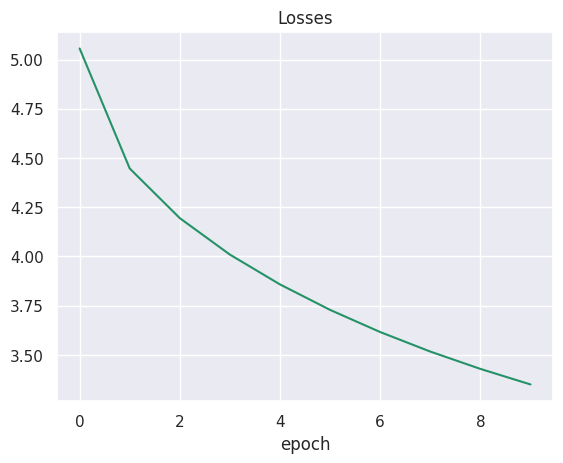

In [72]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

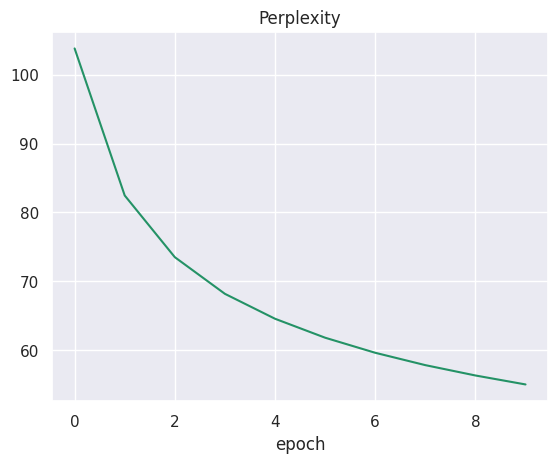

In [73]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Во втором эксперименте добавлю dropout, batch_norm, layer_norm, residual dropout (то есть добавлю различные методы нормализации)

In [75]:
class LanguageModelV2(nn.Module):
    def __init__(self, hidden_dim, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])
        self.embedding_dropout = nn.Dropout(p=0.2)

        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            batch_first=True,
            dropout=0.2
        )
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.tanh = nn.Tanh()

        self.batch_norm = nn.BatchNorm1d(hidden_dim)

        self.residual_dropout = nn.Dropout(p=0.2)

        self.projection = nn.Linear(hidden_dim, vocab_size)


    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        out = self.embedding(input_batch)
        out = self.embedding_dropout(out)
        out, _ = self.lstm(out)

        out = self.layer_norm1(out)
        # для resideal dropout
        residual = out

        out = self.linear(out)
        out = self.tanh(out)

        out = out.transpose(1, 2)  # (batch, features, seq_len)
        out = self.batch_norm(out)
        out = out.transpose(1, 2)  # обратно

        out = out + residual
        out = self.residual_dropout(out)

        out = self.projection(out)

        return out

In [76]:
# Обучите модель здесь
model_v2, losses, perplexities = train_model(LanguageModelV2(hidden_dim=256, vocab_size=len(vocab)).to(device), train_dataloader, eval_dataloader)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Training epoch = 1:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 1: Train Loss = 4.9884, Eval Perplexity = 97.1153


Training epoch = 2:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 2: Train Loss = 4.5361, Eval Perplexity = 80.4939


...

Epoch 8: Train Loss = 3.9923, Eval Perplexity = 58.3593


Training epoch = 9:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 9: Train Loss = 3.9523, Eval Perplexity = 56.8291


Training epoch = 10:   0%|          | 0/2486 [00:00<?, ?it/s]

Epoch 10: Train Loss = 3.9182, Eval Perplexity = 55.5805


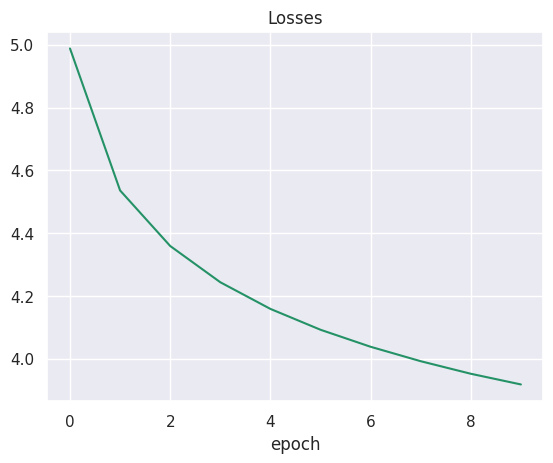

In [77]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

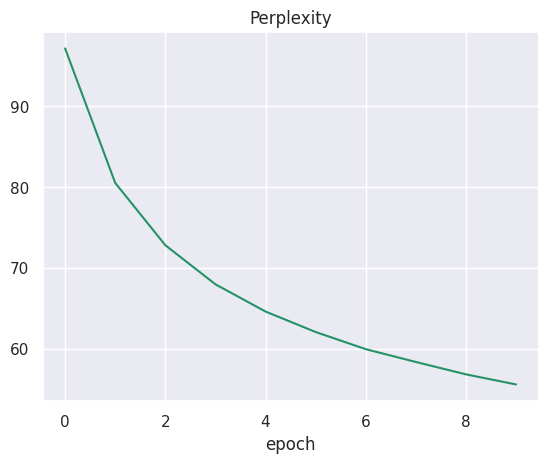

In [78]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

In [88]:
# подсчет перплексии на тесте и трейне для формирования итоговой таблицы с выводами
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

per_test_1 = evaluate(model, dataloader=test_dataloader, criterion=criterion)
per_test_2 = evaluate(model_v2, dataloader=test_dataloader, criterion=criterion)

per_train_1 = evaluate(model, dataloader=train_dataloader, criterion=criterion)
per_train_2 = evaluate(model_v2, dataloader=train_dataloader, criterion=criterion)

print(f'Перплексия первой модели на\n1. Трейне: {per_test_1}\n2. Тесте: {per_train_1}')
print(f'Перплексия второй модели на\n1. Трейне: {per_test_2}\n2. Тесте: {per_train_2}')

Перплексия первой модели на
1. Трейне: 54.26157760620117
2. Тесте: 26.749095916748047
Перплексия второй модели на
1. Трейне: 54.981727600097656
2. Тесте: 34.73147964477539


In [ ]:
text_1 = f'В первой модели использовал LSTM (1 слой), использовал гиперболический тангенс, без нормализации'
res_1 = f'Модель с первых эпох выдавала перплексию >100, за 10 эпох опустилась до ~55 на трейне. Если увеличить число эпох, то, вероятнее всего, тренд на понижение переплексии продолжится. Общий итог: модель обучилась средне, не хватило эпох'

text_2 = f'Добавил нормализацию - dropout, batch_norm, layer_norm, residual dropout. Остальные параметры оставил без изменений'
res_2 = f'Перплексия с первой же эпохи значительно ниже по сравнению в первой моделью. Внедрение нормализации однозначно дало буст. Кроме того отмечу, что сама модель обучалась на две минуты дольше (50 минут против 48 у первой). Опять же, тренд на уменьшение перплексии явный, поэтому предположение о необходимости увеличения числа эпох, вероятно, применимо и здесь'



In [ ]:
import pandas as pd

results_data = {
    'Модель': ['Модель 1 (Базовая)', 'Модель 2 (С нормализацией)'],
    'Описание архитектуры': [text_1, text_2],
    'Перплексия (Трейн)': [per_train_1, per_train_2],
    'Перплексия (Тест)': [per_test_1, per_test_2],
    'Разница (Трейн-Тест)': [abs(per_train_1 - per_test_1), abs(per_train_2 - per_test_2)],
    'Время обучения': ['~48 минут', '~50 минут'],
    'Выводы и наблюдения': [res_1, res_2]
}

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

results_df = pd.DataFrame(results_data)
results_df